In [1]:
using CairoMakie
using DifferentialEquations
using SymPy
using LinearAlgebra

In [70]:
function prey_predator!(du, u, param, t)
    x,y  = u
    alpha, beta, gamma, delta = param
    du[1] = alpha*x - beta*x*y
    du[2] = delta*x*y - gamma * y
end

prey_predator! (generic function with 1 method)

## Nullclines

In [71]:
function just_prey(u, param)
    (x,y)  = u
    alpha, beta, gamma, delta = param
    return alpha*x - beta*x*y
end

just_prey (generic function with 1 method)

In [78]:
function just_predate(u, param)
    (x,y) = u
    alpha, beta, gamma, delta = param
    return delta*x*y- gamma*y
end

just_predate (generic function with 1 method)

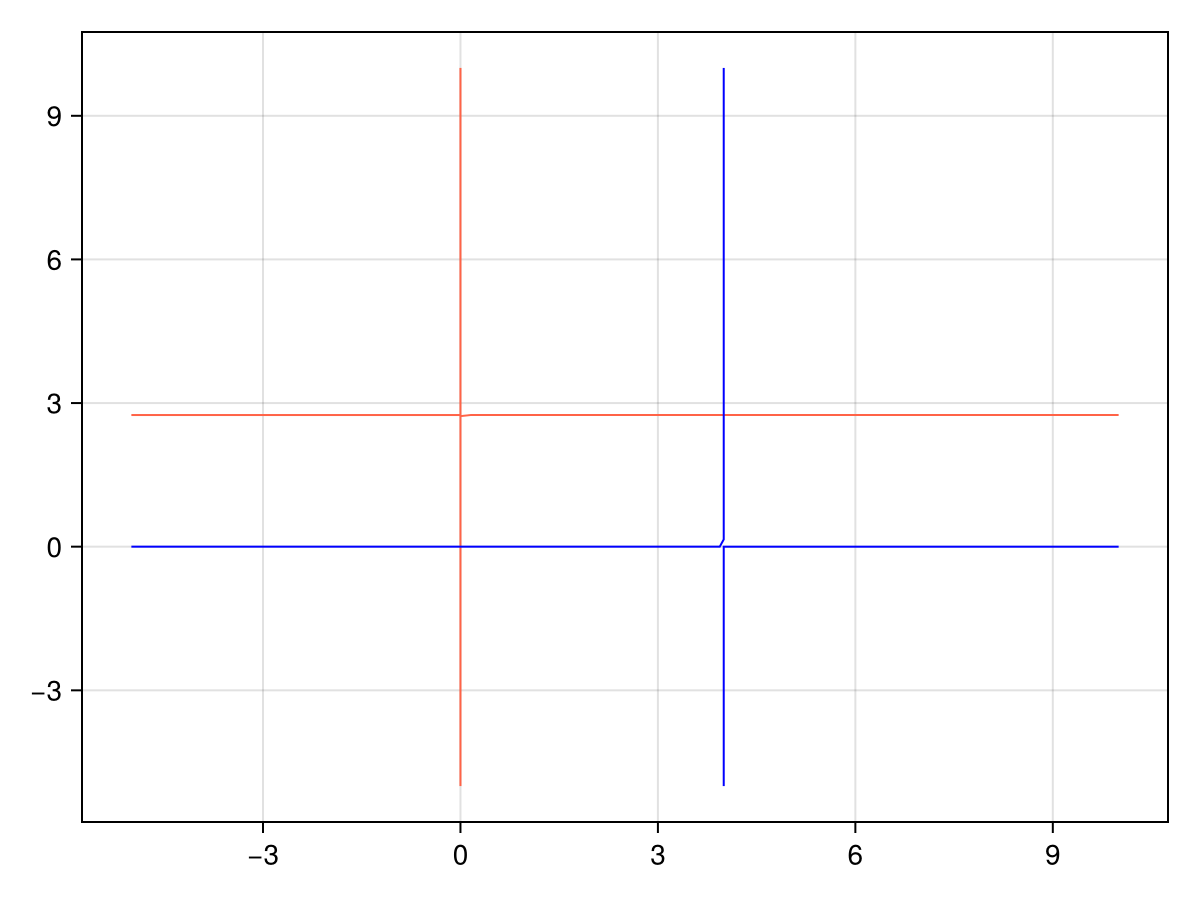

In [82]:
xs = LinRange(-5,10.0,100)
ys = LinRange(-5,10.0,100)


params = [1.1, 0.4, 0.4, 0.1]
dxs = [just_prey([x,y], params) for x in xs, y in ys]
dys = [just_predate([x,y], params) for x in xs, y in ys]
contour(xs,ys,dxs,levels=[0.0], color=:tomato)
contour!(xs,ys,dys,levels=[0.0], color=:blue)
current_figure()

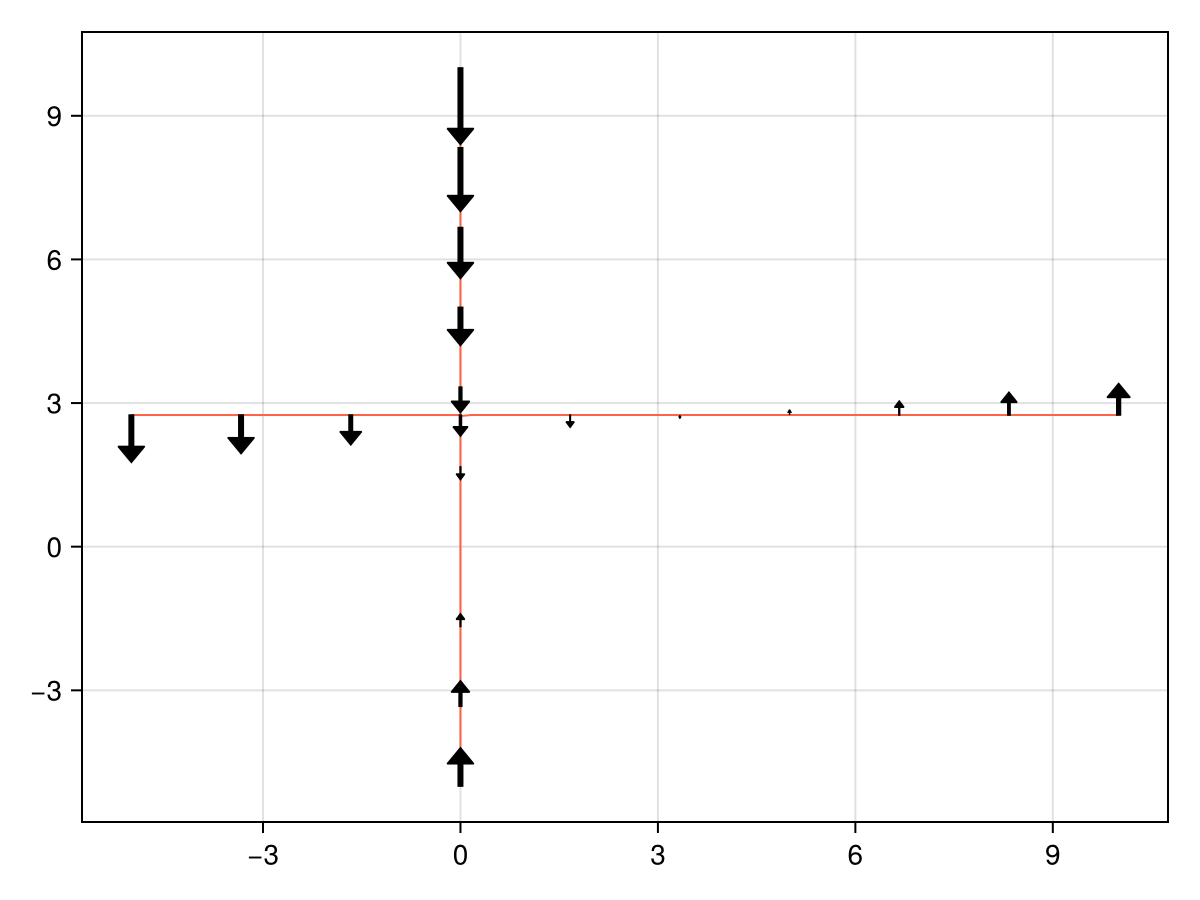

In [90]:
xs = LinRange(-5,10.0,100)
ys = LinRange(-5,10.0,100)


params = [1.1, 0.4, 0.4, 0.1]
alpha, beta, gamma, delta = params
dxs = [just_prey([x,y], params) for x in xs, y in ys]
dys = [just_predate([x,y], params) for x in xs, y in ys]
contour(xs,ys,dxs,levels=[0.0], color=:tomato)

xs_few = LinRange(-5,10.0,10)
ys_few = LinRange(-5,10.0,10)

u_along = [(0,y_now) for y_now in ys_few ]
arrows2d!(zeros(length(ys_few)), ys_few, [0.0], [just_predate(u_now, params) for u_now in u_along], lengthscale=0.4)

u_along = [(x_now, alpha/beta) for x_now in xs_few]
arrows2d!(xs_few, (alpha/beta)ones(length(xs_few)), [0.0], [just_predate(u_now, params) for u_now in u_along], lengthscale=0.4)


current_figure()

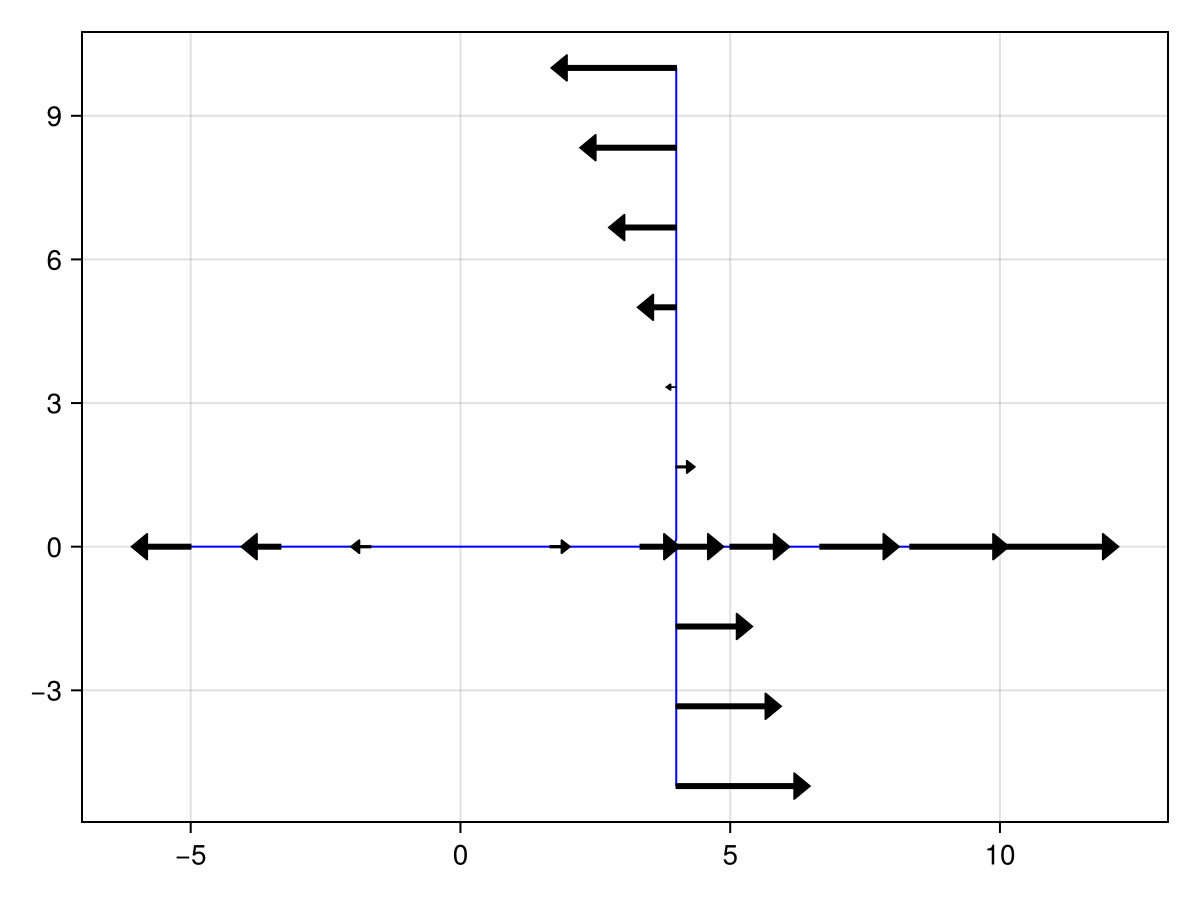

In [93]:
xs = LinRange(-5,10.0,100)
ys = LinRange(-5,10.0,100)


params = [1.1, 0.4, 0.4, 0.1]
alpha, beta, gamma, delta = params
dxs = [just_prey([x,y], params) for x in xs, y in ys]
dys = [just_predate([x,y], params) for x in xs, y in ys]
contour(xs,ys,dys,levels=[0.0], color=:blue)

xs_few = LinRange(-5,10.0,10)
ys_few = LinRange(-5,10.0,10)

u_along = [((gamma/delta),y_now) for y_now in ys_few ]
arrows2d!((gamma/delta)*ones(length(ys_few)), ys_few,  [just_prey(u_now, params) for u_now in u_along], [0.0], lengthscale=0.2)

u_along = [(x_now, 0.0) for x_now in xs_few]
arrows2d!(xs_few, zeros(length(xs_few)), [just_prey(u_now, params) for u_now in u_along], [0.0], lengthscale=0.2)


current_figure()

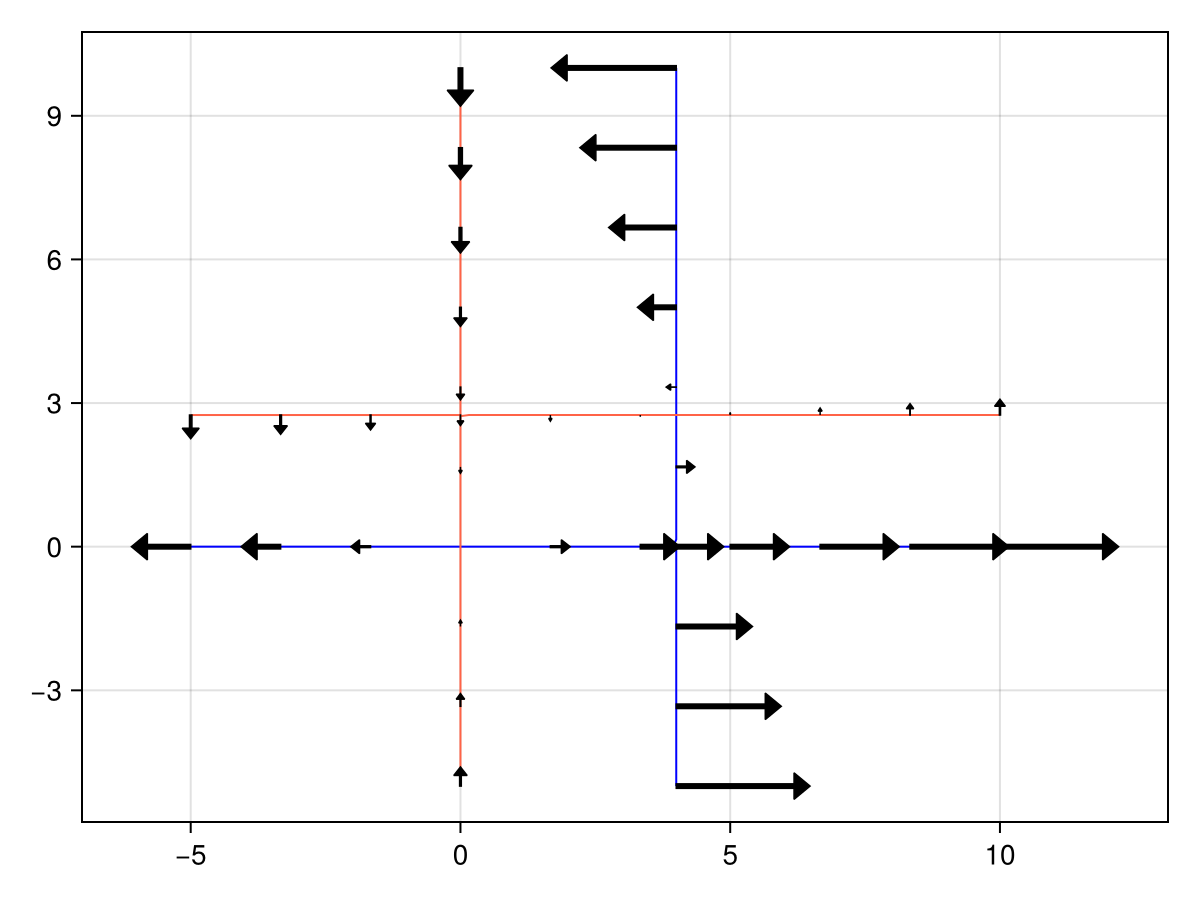

In [97]:
xs = LinRange(-5,10.0,100)
ys = LinRange(-5,10.0,100)

fig = Figure(figsize=(700,700))
ax = Axis(fig[1,1])

params = [1.1, 0.4, 0.4, 0.1]
alpha, beta, gamma, delta = params
dxs = [just_prey([x,y], params) for x in xs, y in ys]
dys = [just_predate([x,y], params) for x in xs, y in ys]
contour!(xs,ys,dys,levels=[0.0], color=:blue)

xs_few = LinRange(-5,10.0,10)
ys_few = LinRange(-5,10.0,10)

u_along = [((gamma/delta),y_now) for y_now in ys_few ]
arrows2d!((gamma/delta)*ones(length(ys_few)), ys_few,  [just_prey(u_now, params) for u_now in u_along], [0.0], lengthscale=0.2)

u_along = [(x_now, 0.0) for x_now in xs_few]
arrows2d!(xs_few, zeros(length(xs_few)), [just_prey(u_now, params) for u_now in u_along], [0.0], lengthscale=0.2)

contour!(xs,ys,dxs,levels=[0.0], color=:tomato)

xs_few = LinRange(-5,10.0,10)
ys_few = LinRange(-5,10.0,10)

u_along = [(0,y_now) for y_now in ys_few ]
arrows2d!(zeros(length(ys_few)), ys_few, [0.0], [just_predate(u_now, params) for u_now in u_along], lengthscale=0.2)

u_along = [(x_now, alpha/beta) for x_now in xs_few]
arrows2d!(xs_few, (alpha/beta)ones(length(xs_few)), [0.0], [just_predate(u_now, params) for u_now in u_along], lengthscale=0.2)

fig


In [40]:
tspan = (0.0,300)
u0=[1.0;0.1]
params = [1, 0.4]
prob = ODEProblem(prey_predator!, u0, tspan, params)

ODEProblem with uType Vector{Float64} and tType Float64. In-place: true
Non-trivial mass matrix: false
timespan: (0.0, 300.0)
u0: 2-element Vector{Float64}:
 1.0
 0.1

In [41]:
sol = solve(prob)

retcode: Success
Interpolation: 3rd order Hermite
t: 39-element Vector{Float64}:
   0.0
   0.07329087821258899
   0.18788524545884344
   0.3344406866034023
   0.5368460149019731
   0.8000886518135608
   1.1483199564187259
   1.5951651582924231
   2.1566345184193767
   2.8410772344762405
   3.6486688783455303
   4.559541162598062
   5.5599777292079615
   ⋮
  49.90604448030692
  53.5315342203974
  56.806747211233564
  60.104062160973506
  63.49598760249386
  66.9856117377411
  74.09982773835183
  83.61400225319204
 102.66472284197181
 146.57079572196585
 285.45682610638573
 300.0
u: 39-element Vector{Vector{Float64}}:
 [1.0, 0.1]
 [0.898092540380032, 0.0996098289913972]
 [0.783452750327479, 0.09776836876075551]
 [0.6843912461494901, 0.09398304387217189]
 [0.5960674121798184, 0.08732144885511856]
 [0.5256955998385531, 0.07772772277066223]
 [0.4716472930045726, 0.06521742418619657]
 [0.4342115220643008, 0.05102679075361229]
 [0.41126748490548015, 0.036869735375271]
 [0.3997212587662394, 0.

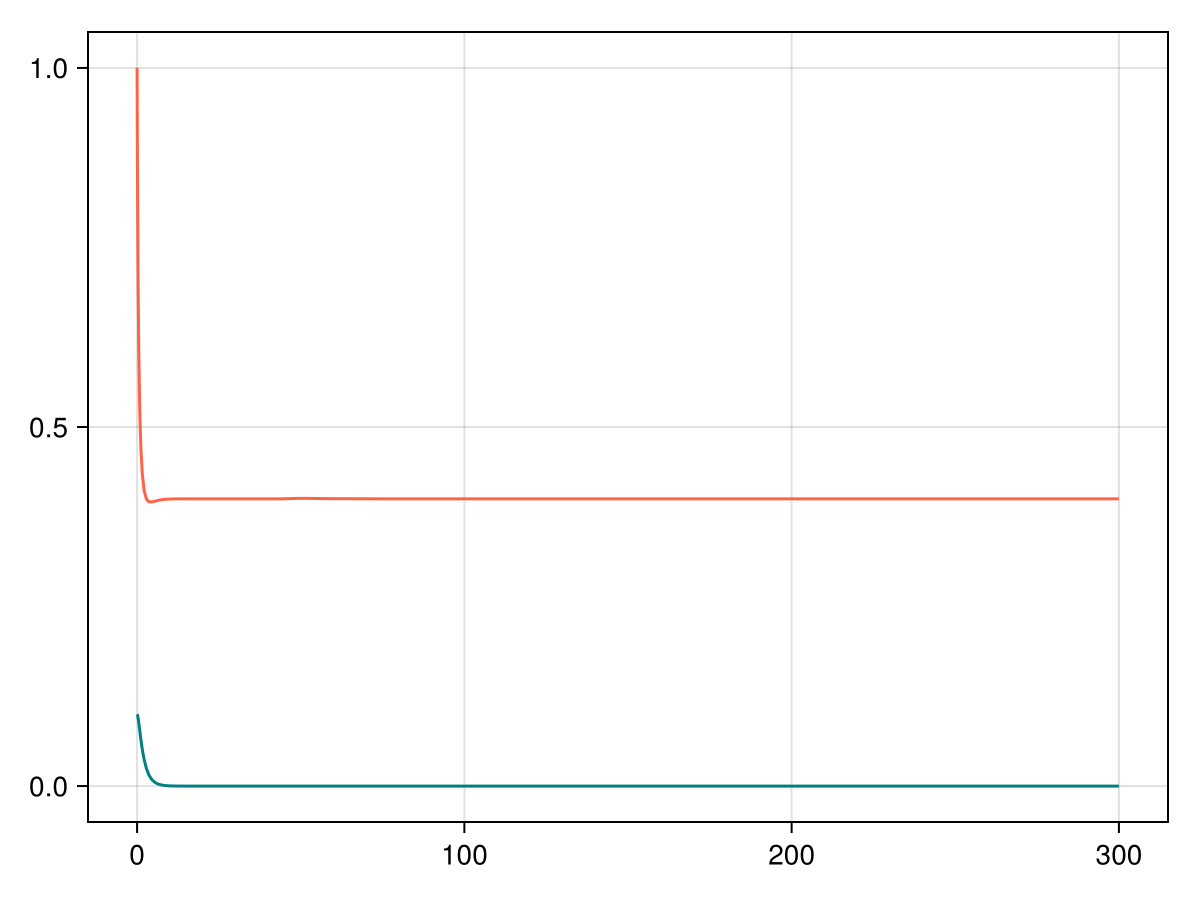

In [50]:
x = getindex.(sol.u, 1)
y = getindex.(sol.u, 2)
lines(sol.t, sol[1,:], color=:tomato)
lines!(sol.t, sol[2,:], color=:teal)
current_figure()

In [30]:
sol.u

1-element Vector{Vector{Float64}}:
 [1.0, 0.1]